# Figure 7
Ghost structures in tipping element model from Wunderling et al 2021 (https://esd.copernicus.org/articles/12/601/2021/)

In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection
import pickle

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


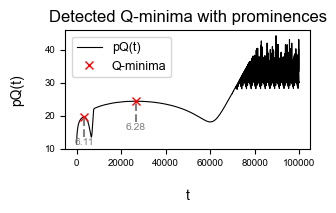

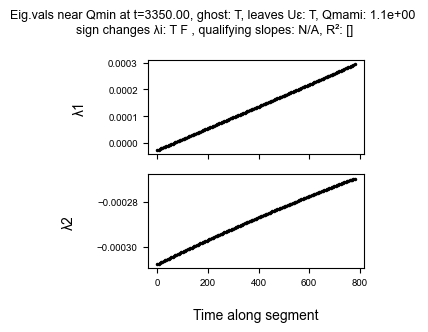

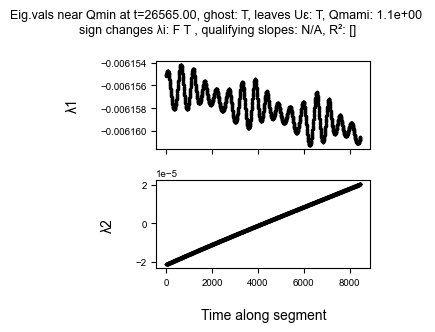

In [2]:
# Set parameters

d = 0.15
GMT = 1.61
Tcrits = np.array([1.5,1.6]) #1.5,1.6
Taus = np.array([500,5000])
interactions=np.array([[0,1],
                    [1,0]])

parameters_Wunderling = [d,GMT,Tcrits,Taus,interactions]

# simulate trajectory (for testing purposes only)
dt = 5
timesteps = np.linspace(0,1e5,int(1e5/dt))
sol = solve_ivp(mod.wunderling_model, (0, 1e5), [-1.5,-1.2], 
                    t_eval=timesteps, args=(parameters_Wunderling,),method='RK45',rtol=1e-4,atol=1e-6)

Trj=sol.y.T
ghostSeqs = gid.ghostID(mod.wunderling_model,parameters_Wunderling,dt,Trj,0.03,peak_kwargs={"prominence":2,"width":50*dt},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":False}) #

Sample phase space to identify all ghosts in the system

In [7]:
import time
start = time.time()
result_pss = gid.ghostID_phaseSpaceSample(mod.wunderling_model,parameters_Wunderling,0,2.5e5,dt,
                                          [np.linspace(-1.5,1.5,21),np.linspace(-1.5,1.5,21)],n_samples=30,seed=1,
                                          peak_kwargs={"prominence":2,"width":50*dt},display_warnings=False,epsilon_gid=0.05,epsilon_SN_ghosts=0.5,epsilon_unify=0.5)
end = time.time()
print(f"Execution time for ghostID_phaseSpaceSample: {end - start} seconds")

with open('result_pss_defaultParams.pkl', 'wb') as f:
    pickle.dump(result_pss, f) 

[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 30/30 [01:08<00:00,  2.29s/IC]

Execution time for ghostID_phaseSpaceSample: 68.6486406326294 seconds


In [3]:
with open('result_pss_defaultParams.pkl', 'rb') as f:
    result_pss = pickle.load(f)
    
ghostList = gid.unique_ghosts(result_pss)
print("Number of unique ghosts identified from phase space sample: ", len(ghostList))


Number of unique ghosts identified from phase space sample:  3


**Figure 6e** (timeseries)

In [ ]:
# plt.figure(figsize=(5*inCm,4*inCm))
# plt.plot(sol.t,sol.y[0],'-',lw=2)
# plt.plot(sol.t,sol.y[1],'-',lw=2)
# plt.xlabel('time (yrs)')
# plt.ylabel('$x_i$')
# plt.ylim(-1.5,1.5)
# ax = plt.gca()
# ax.set_xlim(-1000,1e5); ax.set_xticks([0,5e4,1e5]); ax.set_xticklabels(['0','5$\\times$10$^4$','10$^5$']);
# plt.savefig("Figure6e.svg")

**Figure 6e** (phase space)

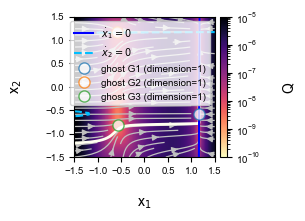

In [9]:
xmin=-1.5;xmax=1.5
ymin=-1.5;ymax=1.5

Ng=100
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.wunderling_model,parameters_Wunderling,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(5*inCm,7*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.wunderling_model(t,z,parameters_Wunderling)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U, V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-10 # Define log scale range 
vmax = 1e-5 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.nullclines_Wunderling(parameters_Wunderling,(-1.5,1.5),(-1.5,1.5),Ng)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot x_1 = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot x_2 = 0$')

# plot ghosts
for i in range(len(ghostList)):
    gi = ghostList[i]
    gx,gy = gi["position"]
    ax.plot(gx,gy,'ow',mec=f'C{i}',markersize=8,alpha=0.75,label=f'ghost {gi["id"]} (dimension={gi["dimension"]})')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel(r"x$_1$")
ax.set_ylabel(r"x$_2$")
ax.set_xlim(xmin,xmax); ax.set_xticks([-1.5,-1,-0.5,0,0.5,1,1.5]);
ax.set_ylim(ymin,ymax); ax.set_yticks([-1.5,-1,-0.5,0,0.5,1,1.5]);
ax.legend(fontsize=7)
plt.savefig("Figure7a.svg")
plt.show()

Identify and plot ghost connections

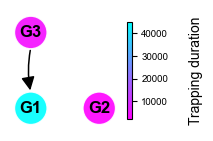

In [10]:
import matplotlib

M, M_labels = gid.ghost_connections(result_pss)

# Get trapping times
durations = [next(g['duration'] for g in ghostList if g['id'] == label) for label in M_labels]

# Normalize durations to [0, 1]
if durations:
    min_dur, max_dur = min(durations), max(durations)
    norm_durations = [(d - min_dur) / (max_dur - min_dur) for d in durations]
else:
    norm_durations = [0.0] * len(M_labels)

# Generate colors using 'cool_r' colormap
cmap = matplotlib.colormaps.get_cmap('cool_r')
nodeColors = [cmap(d) for d in norm_durations]

plt.figure(figsize=(4.5*inCm,4*inCm))
gid.draw_network(M, nodeColors, M_labels, layout="hierarchical",rankdir="BT",node_size=550,label_font_size=12)
plt.gca().margins(0.3)
plt.axis("off")

# Add colorbar
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=min(durations), vmax=max(durations))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.8)
cbar.set_label('Trapping duration')
cbar.set_ticks([1e4,2e4,3e4,4e4])  # Replace with your desired tick positions

plt.savefig("Figure7b.svg")
plt.show()

<>:159: SyntaxWarning: invalid escape sequence '\D'
<>:159: SyntaxWarning: invalid escape sequence '\D'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_11004\3842026079.py:159: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("$\Delta$GMT")
Progress: 100.00% | param value=3.01000: 100%|██████████| 21/21 [00:35<00:00,  1.68s/it]
Progress: 100.00% | param value=3.01000: 100%|██████████| 21/21 [00:34<00:00,  1.62s/it]
Progress: 100.00% | param value=3.01000: 100%|██████████| 21/21 [00:35<00:00,  1.70s/it]
Progress:  80.00% | param value=1.49000:  67%|██████▋   | 4/6 [00:06<00:03,  1.52s/it]


No further ghosts found.


Progress: 100.00% | param value=1.46000: 100%|██████████| 6/6 [00:07<00:00,  1.32s/it]
Progress: 100.00% | param value=1.46000:  83%|████████▎ | 5/6 [00:07<00:01,  1.55s/it]

No further ghosts found.


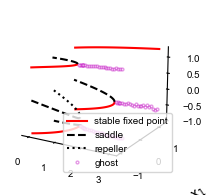

In [11]:
# load bifurcation data from XPPAUT for plotting
with open("Fig7_wunderling_stable1.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []
for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))
dat_stable1 = np.asarray(data)

with open("Fig7_wunderling_stable2.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []
for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))
dat_stable2 = np.asarray(data)

with open("Fig7_wunderling_stable3.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []
for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))
dat_stable3 = np.asarray(data)

with open("Fig7_wunderling_stable4.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []
for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))
dat_stable4 = np.asarray(data)

with open("Fig7_wunderling_repeller.dat") as f:
    lines = f.readlines()
    text = "".join(lines)

data = []
for l in lines:
    row = []
    for n in l.split(' ')[:len(l.split(' '))-1]: 
        row.append(float(n))
    data.append(np.asarray(row))
dat_repeller = np.asarray(data)


fig = plt.figure(figsize=(6*inCm,5.5*inCm)) #5*inCm,4.5*inCm
ax = fig.add_subplot(projection='3d')

# plot SN-bifurcations from XPPAUT

# branches from stable 1
id_SN = 0
id_SN_end = 39
ax.plot3D(dat_stable1[id_SN:id_SN_end,3],dat_stable1[id_SN:id_SN_end,6],dat_stable1[id_SN:id_SN_end,7],'-r',label='stable fixed point')
ax.plot3D(dat_stable1[id_SN_end:,3],dat_stable1[id_SN_end:,6],dat_stable1[id_SN_end:,7],'--k',label='saddle')

# branches from stable 2
id_SN = 0
id_SN_end = 37
ax.plot3D(dat_stable2[id_SN:id_SN_end,3],dat_stable2[id_SN:id_SN_end,6],dat_stable2[id_SN:id_SN_end,7],'-r')
ax.plot3D(dat_stable2[id_SN_end:,3],dat_stable2[id_SN_end:,6],dat_stable2[id_SN_end:,7],'--k')

# branches from stable 3
id_SN = 0
id_SN_end = 36
ax.plot3D(dat_stable3[id_SN:id_SN_end,3],dat_stable3[id_SN:id_SN_end,6],dat_stable3[id_SN:id_SN_end,7],'-r')
ax.plot3D(dat_stable3[id_SN_end:,3],dat_stable3[id_SN_end:,6],dat_stable3[id_SN_end:,7],'--k')

# branches from stable 4
ax.plot3D(dat_stable4[:,3],dat_stable4[:,6],dat_stable4[:,7],'-r')

# branches from repeller
id_SN = 0
id_SN_end = 39
ax.plot3D(dat_repeller[id_SN:id_SN_end,3],dat_repeller[id_SN:id_SN_end,6],dat_repeller[id_SN:id_SN_end,7],':k',label='repeller')
ax.plot3D(dat_repeller[id_SN_end:,3],dat_repeller[id_SN_end:,6],dat_repeller[id_SN_end:,7],'--k')

# track ghost branches
# gpos0, pars0, gSeq0 =  gid.track_ghost_branch(uniqueGhosts[0], wunderling_modeljx_listpara, pars, 1, 20, 0.1, 1e3, 5, delta=0.2, icStep=0.4, mode="closest", 
#                              epsilon_gid=0.1,solve_ivp_method='LSODA', qmin_method="BFGS",qmin_tol=1e-6,peak_kwargs={"prominence":0.1,"width":0},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":False})


positions_ghosts_1fwd, paramVals_1fwd, _ =  gid.track_ghost_branch(ghostList[0], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 20, 0.07, 1e5, dt, delta=0.2, icStep=0.45,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",#, qmin_loc_method="BFGS",
                                                                 qmin_glob_options={"seed":15,"n_samples":600},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}

positions_ghosts_2fwd, paramVals_2fwd, _ =  gid.track_ghost_branch(ghostList[1], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 20, 0.07, 1e5, dt, delta=0.15, icStep=0.4,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",
                                                                 qmin_glob_options={"seed":3,"n_samples":400},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}

positions_ghosts_3fwd, paramVals_3fwd, _ =  gid.track_ghost_branch(ghostList[2], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 20, 0.07, 1e5, dt, delta=0.15, icStep=0.4,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",
                                                                 qmin_glob_options={"seed":3,"n_samples":400},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}
################################
positions_ghosts_1rev, paramVals_1rev, _ =  gid.track_ghost_branch(ghostList[0], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 5, -0.03, 1e5, dt, delta=0.2, icStep=0.45,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",#, qmin_loc_method="BFGS",
                                                                 qmin_glob_options={"seed":15,"n_samples":600},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}

positions_ghosts_2rev, paramVals_2rev, _ =  gid.track_ghost_branch(ghostList[1], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 5, -0.03, 1e5, dt, delta=0.15, icStep=0.4,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",
                                                                 qmin_glob_options={"seed":3,"n_samples":400},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}

positions_ghosts_3rev, paramVals_3rev, _ =  gid.track_ghost_branch(ghostList[2], mod.wunderling_model, parameters_Wunderling, 
                                                                 1, 5, -0.03, 1e5, dt, delta=0.15, icStep=0.4,# mode="closest", 
                                                                 epsilon_gid=0.1,evLimit=0, peak_kwargs={"prominence":0,"width":20*dt},
                                                                 solve_ivp_method='RK45',rtol=1e-5,atol=1e-6,
                                                                 distQminThr=0.2, qmin_glob_method="lhs",
                                                                 qmin_glob_options={"seed":3,"n_samples":400},
                                                                 ctrlOutputs={"ctrl_qplot":False},display_warnings=False) #7 #qmin_glob_options={"seed":None,"n_samples":150} qmin_glob_options={"seed":1,"n_samples":400}

ax.plot3D(paramVals_1rev, positions_ghosts_1rev[:,0],positions_ghosts_1rev[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4,label='ghost')#, zorder=1)
ax.plot3D(paramVals_2rev, positions_ghosts_2rev[:,0],positions_ghosts_2rev[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4)#, zorder=1)
ax.plot3D(paramVals_3rev, positions_ghosts_3rev[:,0],positions_ghosts_3rev[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4)#, zorder=1)

ax.plot3D(paramVals_1fwd, positions_ghosts_1fwd[:,0],positions_ghosts_1fwd[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4)#, zorder=1)
ax.plot3D(paramVals_2fwd, positions_ghosts_2fwd[:,0],positions_ghosts_2fwd[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4)#, zorder=1)
ax.plot3D(paramVals_3fwd, positions_ghosts_3fwd[:,0],positions_ghosts_3fwd[:,1],'-o',ms=2,color='w',mec='m',alpha=0.4)#, zorder=1)

fun.noBackground(ax)

plt.legend(fontsize=7)
ax.set_xlabel("$\Delta$GMT")
ax.set_ylabel(r"x$_1$")
ax.set_zlabel(r"x$_2$")

ax.view_init(elev=18, azim=-60)
plt.savefig("Figure7c.svg")

Dimension bifurcation

In [ ]:
results_pss_tau1 = []

for i in range(20):

    tau1 = 500 + i*1000

    d = 0.15
    GMT = 1.61
    Tcrits = np.array([1.5,1.6])
    Taus = np.array([tau1,5000])
    interactions=np.array([[0,1],
                        [1,0]])

    parameters_Wunderling_i = [d,GMT,Tcrits,Taus,interactions]

    result_pss = gid.ghostID_phaseSpaceSample(mod.wunderling_model,parameters_Wunderling_i,0,4e5,dt,
                                            [np.linspace(-1.5,1.5,21),np.linspace(-1.5,1.5,21)],n_samples=100,seed=1,
                                            peak_kwargs={"prominence":2,"width":50*dt},display_warnings=False,epsilon_gid=0.03,epsilon_SN_ghosts=0.65,epsilon_unify=0.65,evLimit=2e-5)
       
    results_pss_tau1.append(result_pss)

# Save results with pickle
with open('result_pss_tau1sweep.pkl', 'wb') as f:
    pickle.dump(results_pss_tau1, f) 


[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 100/100 [07:56<00:00,  4.77s/IC]


[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 100/100 [02:41<00:00,  1.61s/IC]


[ghostID_phaseSpaceSample] Running with threads (11 workers)


...

Processing ICs: 100%|██████████| 100/100 [00:49<00:00,  2.01IC/s]


[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 100/100 [00:49<00:00,  2.00IC/s]


[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 100/100 [00:54<00:00,  1.85IC/s]


In [5]:
with open('result_pss_tau1sweep.pkl', 'rb') as f:
    results_pss_tau1 = pickle.load(f)

for i_tau in range(len(results_pss_tau1)):
    for i_samples in range(len(results_pss_tau1[i_tau])):
        for i_ghost in range(len(results_pss_tau1[i_tau][i_samples])):

            g = results_pss_tau1[i_tau][i_samples][i_ghost]

            distances = [np.linalg.norm(np.array(g["position"]) - np.array(ghostList[i]["position"])) for i in range(len(ghostList))]

            idx_closest = np.argmin(distances)

            results_pss_tau1[i_tau][i_samples][i_ghost]["id"] = ghostList[idx_closest]["id"]


tau1_values = [500 + i*1000 for i in range(20)]

ghost_positions_tau1 = []
ghost_dimensions_tau1 = []

adjacency_matrices_tau1 = []
adjacency_matrices_tau1_lbls = []

for i in range(len(results_pss_tau1)):

    unique_ghosts = gid.unique_ghosts(results_pss_tau1[i])


    distances_to_ghost1 = [np.linalg.norm(np.array(g["position"]) - np.array(ghostList[0]["position"])) for g in unique_ghosts]
    distances_to_ghost2 = [np.linalg.norm(np.array(g["position"]) - np.array(ghostList[1]["position"])) for g in unique_ghosts]
    distances_to_ghost3 = [np.linalg.norm(np.array(g["position"]) - np.array(ghostList[2]["position"])) for g in unique_ghosts]

    idx_ghost1 = np.argmin(distances_to_ghost1)
    idx_ghost2 = np.argmin(distances_to_ghost2)
    idx_ghost3 = np.argmin(distances_to_ghost3)

    dim_gi = [unique_ghosts[idx_ghost1]["dimension"], unique_ghosts[idx_ghost2]["dimension"], unique_ghosts[idx_ghost3]["dimension"]]
    pos_gi = [unique_ghosts[idx_ghost1]["position"], unique_ghosts[idx_ghost2]["position"], unique_ghosts[idx_ghost3]["position"] ]

    ghost_dimensions_tau1.append(dim_gi)
    ghost_positions_tau1.append(pos_gi)
    # unified_ghosts_ = gid.unify_IDs(ghostList_tau1_fullgrid, 0.5,False)
    
    # # extract adjacency matrix
    M_tau1, M_labels_tau1 = gid.ghost_connections(results_pss_tau1[i])
    # M_labels_tau1 = [unique_ghosts[idx_ghost1]["id"], unique_ghosts[idx_ghost2]["id"], unique_ghosts[idx_ghost3]["id"]]
    adjacency_matrices_tau1.append(M_tau1)
    adjacency_matrices_tau1_lbls.append(M_labels_tau1)

ghost_dimensions_tau1 = np.array(ghost_dimensions_tau1)
ghost_positions_tau1 = np.array(ghost_positions_tau1)


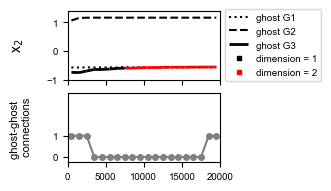

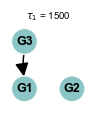

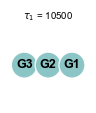

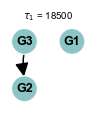

In [27]:
colors = [['r' if dim == 2 else 'k' for dim in ghost_dimensions_tau1[:,i]] for i in range(3)]

def plot_colored_line(x, y, colors, ax, label=None, lw=1,zorder=1,linestyle='-'):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    # print("segments shape:", segments.shape)  # Debug
    lc = LineCollection(segments, colors=colors, linewidths=lw,linestyle=linestyle, label=label, zorder=zorder)
    ax.add_collection(lc)
    return lc

# Create figure
# fig, ax = plt.subplots(figsize=(5*inCm, 4.5*inCm))

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(5*inCm, 5*inCm))

# Plot Ghosts
for i in range(3):
    if sum(ghost_dimensions_tau1[:,i])>len(ghost_dimensions_tau1[:,i]):
        plot_colored_line(tau1_values, ghost_positions_tau1[:,i,1], colors[i], ax1, label=f'ghost G{i+1}',zorder=i, lw=2,linestyle=[':','--','-'][i])
    else:
        ax1.plot(tau1_values, ghost_positions_tau1[:,i,1],'k', label=f'ghost G{i+1}',zorder=i, lw=1.5,linestyle=[':','--','-'][i])

ax1.plot([], [], 's',color='k', ms=3, label='dimension = 1')
ax1.plot([], [], 's',color='r', ms=3, label='dimension = 2')

# Set axis limits
ax1.set_xlim(0,20000)
ax1.set_xticks([0,5000,10000,15000,20000],[])
ax1.set_ylim(-1,1.4)

ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize=7)

ax1.set_ylabel(r"x$_2$")


### remove spurious gi->gi links resulting from double-counted peaks
for i in range(len(adjacency_matrices_tau1)):
    for ii in range(3): adjacency_matrices_tau1[i][ii,ii] = 0

ghostConnections_vs_tau1 = [np.sum(adjacency_matrices_tau1[i]) for i in range(len(adjacency_matrices_tau1))]
# for i in range(len(adjacency_matrices_tau1)): print(adjacency_matrices_tau1[i])
ax2.plot(tau1_values,ghostConnections_vs_tau1,'-o',ms=4,color='grey')

ax2.set_ylim(-0.25,3)
ax2.set_yticks([0,1])
ax2.set_ylabel('ghost-ghost \n connections',fontsize=8)
ax2.set_xlim(0,20000)
ax1.set_xlabel(r"$\tau_1$")
plt.savefig("Figure7d.svg")


for i in [1,10,18]:
    M = adjacency_matrices_tau1[i]
    M_labels = adjacency_matrices_tau1_lbls[i]
    node_colors = [(0.5, 0.75, 0.75)] * 3
    plt.figure(figsize=(2.5*inCm,2.5*inCm))
    plt.title(f"$\\tau_1$ = {tau1_values[i]}", fontsize=7)
    if i == 1:
        rd = "BT" 
    else:
        rd = "TB"
    gid.draw_network(M, node_colors, M_labels, layout="hierarchical",rankdir=rd,node_size=350,label_font_size=9)
    plt.gca().margins(0.3)
    plt.axis("off")
    plt.savefig(f"Figure7d_graph_tau1_{i}.svg")


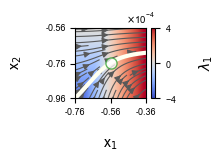

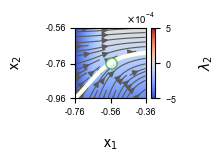

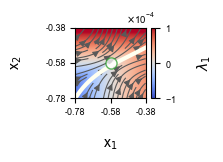

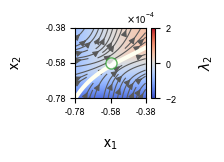

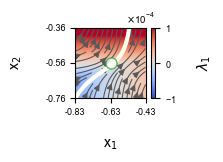

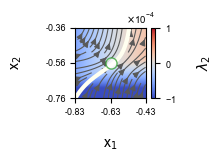

In [25]:
from matplotlib.ticker import ScalarFormatter


def eigValsOnGrid_system1(X_grid, Y_grid, para):

    tau1,tau2,d,s12,s21 = para

    lambda1 = np.zeros_like(X_grid)
    lambda2 = np.zeros_like(X_grid)

    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            x1,x2 = [X_grid[i, j], Y_grid[i, j]]

            term1 = (1 - 3 * x1**2) / tau1
            term2 = (1 - 3 * x2**2) / tau2
            inside_sqrt = (term1 + term2)**2 - (4 / (tau1 * tau2)) * ((1 - 3 * x1**2) * (1 - 3 * x2**2) - (d**2 * s21 * s12) / 100)
            sqrt_term = np.sqrt(inside_sqrt)
            lambda1[i,j]= 0.5 * (term1 + term2) + 0.5 * sqrt_term
            lambda2[i,j]= 0.5 * (term1 + term2) - 0.5 * sqrt_term

    return [lambda1, lambda2]


for i in [1,10,18]:
    
    xmin=ghost_positions_tau1[i,2,0]-0.2;xmax=ghost_positions_tau1[i,2,0]+0.2
    ymin=ghost_positions_tau1[i,2,1]-0.2;ymax=ghost_positions_tau1[i,2,1]+0.2

    Ng=100
    x_range=np.linspace(xmin,xmax,Ng)
    y_range=np.linspace(ymin,ymax,Ng)
    grid_ss = np.meshgrid(x_range, y_range)
    Xg,Yg=grid_ss


    d = 0.15
    GMT = 1.61
    Tcrits = np.array([1.5,1.6])
    tau1=tau1_values[i]
    Taus = np.array([tau1,5000])
    interactions=np.array([[0,1],
                        [1,0]])

    parameters_Wunderling_2 = [d,GMT,Tcrits,Taus,interactions]
    lambdas = eigValsOnGrid_system1(Xg, Yg,[tau1,5000,d,1,1])

    def flow_model(t,z): 
            return mod.wunderling_model(t,z,parameters_Wunderling_2)
    U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

    for ii in range(2):
        plt.figure(figsize=(2.6*inCm,2.6*inCm))
        ax = plt.gca()

        ax.streamplot(  Xg, Yg,
                        U, V,
                        density=0.55,
                        color=[0.35, 0.35, 0.35, 1],
                        arrowsize=0.9,
                        linewidth=0.8)
        
        vmin=float(np.min(np.asarray(lambdas[ii])))
        vmax=float(np.max(np.asarray(lambdas[ii])))
        vmax = np.round(max(abs(vmin), abs(vmax)),4)
        vmin = -vmax

        im = ax.imshow(lambdas[ii], extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='coolwarm', vmin=vmin, vmax=vmax) 

        # plot trajectory
        dt = 5
        timesteps = np.linspace(0,2e5,int(2e5/dt))
        sol = solve_ivp(mod.wunderling_model, (0, 2e5), [xmin,ymin], 
                            t_eval=timesteps, args=(parameters_Wunderling_2,),method='RK45',rtol=1e-4,atol=1e-6)

        ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=3)



        # plot ghosts
    
        gx,gy = ghost_positions_tau1[i,2,:]
        ax.plot(gx,gy,'ow',mec=f'C2',markersize=8,alpha=0.75,label=f'ghost 3 (dimension={ghost_dimensions_tau1[i,2]})')

        # # add colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="6%", pad=0.05)
        cb = plt.colorbar(im, cax=cax,label=f"$\\lambda_{ii+1}$")
        cb.set_ticks([vmin,0,vmax])
        cb.ax.tick_params(labelsize=6.5)  # Adjust the size as needed
        # Format the tick labels to scientific notation
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))  # always use scientific notation
        cb.ax.yaxis.set_major_formatter(formatter)
        
        # Explicitly control the size of the tick labels
        

        #labels, limits, legend
        ax.set_xlabel(r"x$_1$")
        ax.set_ylabel(r"x$_2$")
        ax.set_xlim(xmin,xmax); ax.set_xticks([xmin,(xmax+xmin)/2,xmax]); 
        ax.set_xticklabels(str(t) for t in np.round([xmin,(xmax+xmin)/2,xmax],2))
        ax.set_ylim(ymin,ymax); ax.set_yticks([ymin,np.round((ymax+ymin)/2,2),ymax]);
        ax.set_yticklabels(str(t) for t in np.round([ymin,(ymax+ymin)/2,ymax],2))
        ax.tick_params(axis='both', which='major', labelsize=6.5)
        
        plt.savefig(f"Figure7e_ghost3_tau1_{tau1}_lambda{ii+1}.svg")

        